# **Code Program**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from skimage.io import imread
from skimage.transform import resize
from skimage.color import gray2rgb, rgba2rgb
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Conv2D, SeparableConv2D,MaxPooling2D, GlobalMaxPooling2D,
                                     Dense, Dropout, Reshape, UpSampling2D, Multiply)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

IMAGE_DIR = r'D:\Belum Rapiin\rice\Rice-Leaf-Disease-Images'
TARGET_SIZE = (64, 64)
N_CLASSES = 5
BATCH_SIZE = 64
EPOCHS = 100


In [11]:
def load_dataset(image_dir, target_size, n_class):

    images, labels = [], []
    valid_class_names = []

    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.gif')

    for class_name in sorted(os.listdir(image_dir)):
        class_path = os.path.join(image_dir, class_name)
        if os.path.isdir(class_path) and any(f.lower().endswith(valid_exts) for f in os.listdir(class_path)):
            valid_class_names.append(class_name)

    valid_class_names = valid_class_names[:n_class]
    class_map = {cls: i for i, cls in enumerate(valid_class_names)}

    for class_name in valid_class_names:
        class_path = os.path.join(image_dir, class_name)
        img_files = sorted([f for f in os.listdir(class_path) if f.lower().endswith(valid_exts)])
        for img_file in img_files:
            img_path = os.path.join(class_path, img_file)
            try:
                img = imread(img_path)
                if img.ndim == 2:
                    img = gray2rgb(img)
                elif img.shape[2] == 4:
                    img = rgba2rgb(img)
                img = resize(img, target_size, preserve_range=True, anti_aliasing=True)
                images.append(img)
                labels.append(class_map[class_name])
            except Exception as e:
                print(f"Error reading {img_path}: {e}")

    images = np.array(images).astype(np.float32) / 255.0
    labels = np.array(labels)
    labels_cat = to_categorical(labels, num_classes=n_class)
    
    print("\n\n================== DATA SHAPE =====================")
    print(f"\nDataset shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")

    return images, labels, labels_cat, valid_class_names


def show_one_sample_per_class(images, labels, class_names):

    sample_per_class = {}

    for img, label in zip(images, labels):
        if label not in sample_per_class:
            sample_per_class[label] = img
        if len(sample_per_class) == len(class_names):
            break

    plt.figure(figsize=(15, 4))
    for i, (label_idx, img) in enumerate(sample_per_class.items()):
        plt.subplot(1, len(sample_per_class), i + 1)
        plt.imshow(img)
        plt.title(f"Class: {class_names[label_idx]}")
        plt.axis('off')

    print("\n\n================== CONTOH 1 GAMBAR PER CLASS =====================")
    plt.tight_layout()
    plt.suptitle("Contoh 1 Gambar per Kelas", y=1.05, fontsize=16)
    plt.show()


In [12]:
def create_datagen():
    return ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

def show_augmented_images(x_train_sample):
    datagens = [
        ("Rotated", ImageDataGenerator(rotation_range=20)),
        ("Shifted", ImageDataGenerator(width_shift_range=0.2, height_shift_range=0.2)),
        ("Zoomed", ImageDataGenerator(zoom_range=0.2)),
        ("Flipped", ImageDataGenerator(horizontal_flip=True))
    ]
    images_aug = [x_train_sample[0]]
    titles = ["Original"]

    for name, datagen in datagens:
        img_aug = next(datagen.flow(x_train_sample, batch_size=1))[0]
        images_aug.append((img_aug*255).astype(np.uint8))
        titles.append(name)

    plt.figure(figsize=(15, 8))
    for i, img in enumerate(images_aug):
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    print("\n\n================== CONTOH AUGMENTASI =====================")
    plt.suptitle("Augmentasi Gambar", y=1.05, fontsize=16)
    plt.show()

In [13]:
def visualize_predictions(images, y_true, y_pred, class_names, confidences, num_images=10):
    import random
    plt.figure(figsize=(12, 8))
    random_indices = random.sample(range(len(images)), num_images)
    for i, idx in enumerate(random_indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[idx])
        plt.axis('off')
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = confidences[idx] * 100
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"T: {true_label}\nP: {pred_label}\n{confidence:.2f}%", color=color)
    plt.tight_layout()
    plt.show()

In [14]:

def evaluate_model(model, x_test, y_test, class_names, encoder=None, history=None, model_name="Model"):
    import time

    if encoder:
        x_input = encoder.predict(x_test)
    else:
        x_input = x_test

    test_loss, test_acc = model.evaluate(x_input, y_test, verbose=0)
    print(f"\n\n================== EVALUASI HASIL EVALUASI =====================")
    print(f"Test Accuracy (from evaluate): {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    
    start = time.time()
    y_pred_probs = model.predict(x_input)
    end = time.time()

    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print("\n\n================== EVALUASI WAKTU =====================")
    print(f"Total prediction time: {end - start:.4f}s")
    print(f"Per sample: {(end - start)/len(x_test):.6f}s")
    print("Test Accuracy (manual): {:.2f}%".format(np.mean(y_pred == y_true) * 100))

    if history:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Train Accuracy')
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title(f'{model_name} Accuracy')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_name} Loss')
        plt.legend()

        plt.tight_layout()
        plt.show()

    print("\n\n================== CONFUSION MATRIX =====================")
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure(figsize=(10, 8))
    disp.plot(cmap='Blues', values_format='.0f')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    print("\n\n================== CLASSIFICATION REPORT =====================")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("\n\n================== VISUALISASI PREDIKSI =====================")
    confidences = np.max(y_pred_probs, axis=1)
    visualize_predictions(x_test, y_true, y_pred, class_names, confidences)

    return y_true, y_pred, y_pred_probs

In [ ]:
def predict_single_image(model, img_path, class_names, target_size=(64, 64), augment=False, encoder=None):
    from skimage.io import imread
    from skimage.transform import resize
    from skimage.color import gray2rgb, rgba2rgb
    import time

    start_time = time.time()

    try:
        img = imread(img_path)

        if img.ndim == 2:
            img = gray2rgb(img)
        elif img.shape[2] == 4:
            img = rgba2rgb(img)

        img = resize(img, target_size, preserve_range=True, anti_aliasing=True)
        img_array = np.array(img).astype(np.float32) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        if augment:
            datagen = create_datagen()
            img_array = next(datagen.flow(img_array, batch_size=1))

        if encoder:
            encoded = encoder.predict(img_array)
        else:
            encoded = img_array

        prediction = model.predict(encoded)
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction)
        predicted_label = class_names[predicted_class]

        end_time = time.time()
        processing_time = end_time - start_time

        plt.imshow(img_array[0])
        plt.title(f"Predicted: {predicted_label} ({confidence:.2f})\nTime: {processing_time:.4f} sec")
        plt.axis('off')
        plt.show()

        return predicted_label, confidence, processing_time

    except Exception as e:
        print(f"Failed to process image {img_path}: {e}")
        return None, 0.0, 0.0

In [7]:
def show_class_distribution(labels, class_names, title):
    counts = np.bincount(labels)
    print(f"\n{title}")
    for i, count in enumerate(counts):
        print(f"- {class_names[i]}: {count} gambar")
    return counts



================== DATA SHAPE =====================

Dataset shape: (7430, 64, 64, 3)
Labels shape: (7430,)

Jumlah Total Data: 7430 gambar

Jumlah Data per Kelas (Sebelum Split)
- Bacterialblight: 1584 gambar
- Blast: 1440 gambar
- Brownspot: 1600 gambar
- Healthy: 1488 gambar
- Tungro: 1318 gambar

Jumlah Data Train per Kelas
- Bacterialblight: 1267 gambar
- Blast: 1152 gambar
- Brownspot: 1280 gambar
- Healthy: 1190 gambar
- Tungro: 1055 gambar

Jumlah Data Test per Kelas
- Bacterialblight: 317 gambar
- Blast: 288 gambar
- Brownspot: 320 gambar
- Healthy: 298 gambar
- Tungro: 263 gambar


================== CONTOH 1 GAMBAR PER CLASS =====================


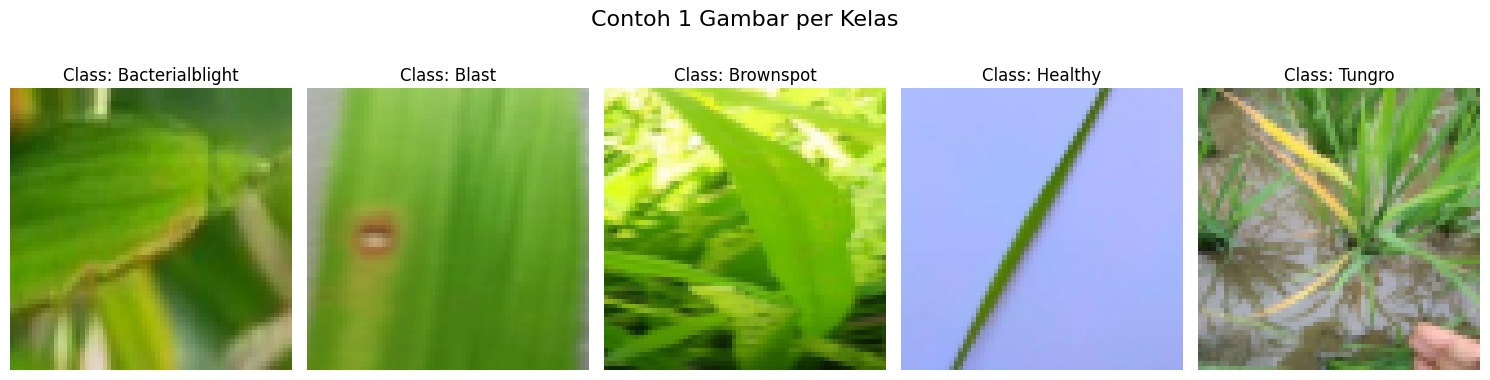



================== CONTOH AUGMENTASI =====================


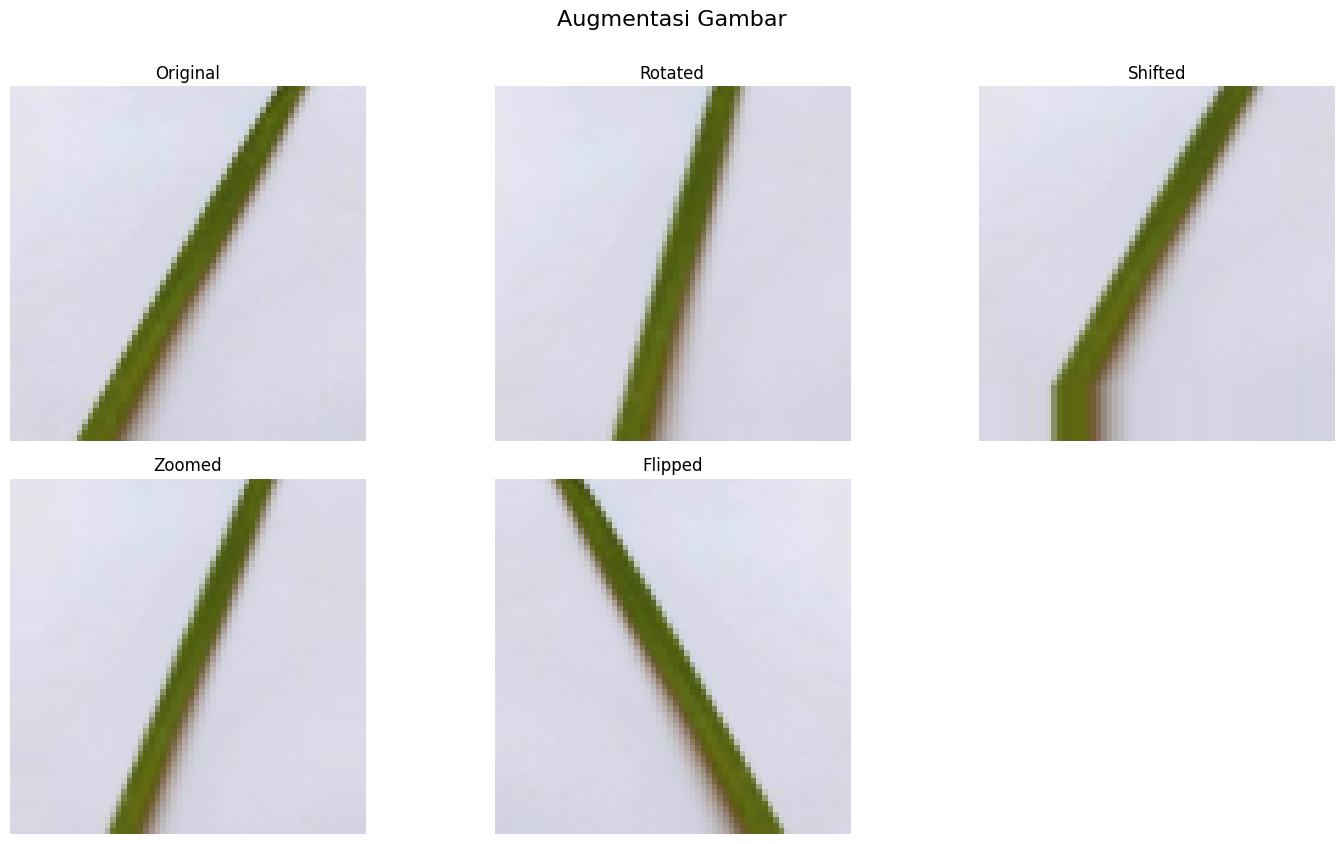

In [8]:
images, labels, labels_cat, class_names = load_dataset(IMAGE_DIR, TARGET_SIZE, N_CLASSES)
x_train, x_test, y_train, y_test = train_test_split(images, labels_cat, test_size=0.2, stratify=labels, random_state=13)

train_labels = np.argmax(y_train, axis=1)
test_labels = np.argmax(y_test, axis=1)

total_data = len(labels)
print(f"\nJumlah Total Data: {total_data} gambar")

_ = show_class_distribution(labels, class_names, "Jumlah Data per Kelas (Sebelum Split)")

_ = show_class_distribution(train_labels, class_names, "Jumlah Data Train per Kelas")
_ = show_class_distribution(test_labels, class_names, "Jumlah Data Test per Kelas")

datagen = create_datagen()
datagen.fit(x_train)

show_one_sample_per_class(images, labels, class_names)
show_augmented_images(np.expand_dims(x_train[2], axis=0))

# CAE+CNN MODEL 1

In [9]:
def build_autoencoder(input_shape=(64, 64, 3)):
    input_img = Input(shape=input_shape)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    max_pool = GlobalMaxPooling2D()(x)
    encoded = Dense(128, activation='relu', name='encoded_vector')(max_pool)

    x = Reshape((1, 1, 128))(encoded)
    x = UpSampling2D((8, 8))(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded, name='Autoencoder')
    encoder = Model(inputs=input_img, outputs=encoded, name='Encoder')

    autoencoder.compile(optimizer='adam', loss='mse')

    print("\n\n================== AUTOENCODER SUMMARY =====================")
    autoencoder.summary()

    return autoencoder, encoder

In [10]:
def build_cnn_classifier(input_dim, num_classes):
    model = Sequential(name='CNN_Classifier')
    model.add(Dense(256, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.5))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("\n\n================== CNN SUMMARY =====================")
    model.summary()

    return model

In [11]:
autoencoder, encoder = build_autoencoder(input_shape=(64, 64, 3))
print("\n\n================== AUTOENCODER TRAINING =====================")
history_autoencoder = autoencoder.fit(
    datagen.flow(x_train, x_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, x_test)
)

print("\n\n================== EKSTRAK ENCODER =====================")
encoded_train = encoder.predict(x_train)
encoded_test = encoder.predict(x_test)






================== AUTOENCODER SUMMARY =====================
Model: "Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                       

In [12]:
classifier = build_cnn_classifier(input_dim=128, num_classes=N_CLASSES)
print("\n\n================== CNN TRAINING =====================")
history_classifier = classifier.fit(
    encoded_train, y_train,
    epochs=EPOCHS,
    validation_data=(encoded_test, y_test)
)



================== CNN SUMMARY =====================
Model: "CNN_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               33024     
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 5)                 645       
                                                                 
Total params: 66565 (260.02 KB)
Trainable params: 66565 (260.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


================== CNN TRAINING =====================
Epoch 1/100

186/186 [=============



================== EVALUASI =====================
47/47 [==============================] - 0s 9ms/step


================== EVALUASI HASIL EVALUASI =====================
Test Accuracy (from evaluate): 0.9933
Test Loss: 0.0134
47/47 [==============================] - 0s 1ms/step


================== EVALUASI WAKTU =====================
Total prediction time: 0.1535s
Per sample: 0.000103s
Test Accuracy (manual): 99.33%


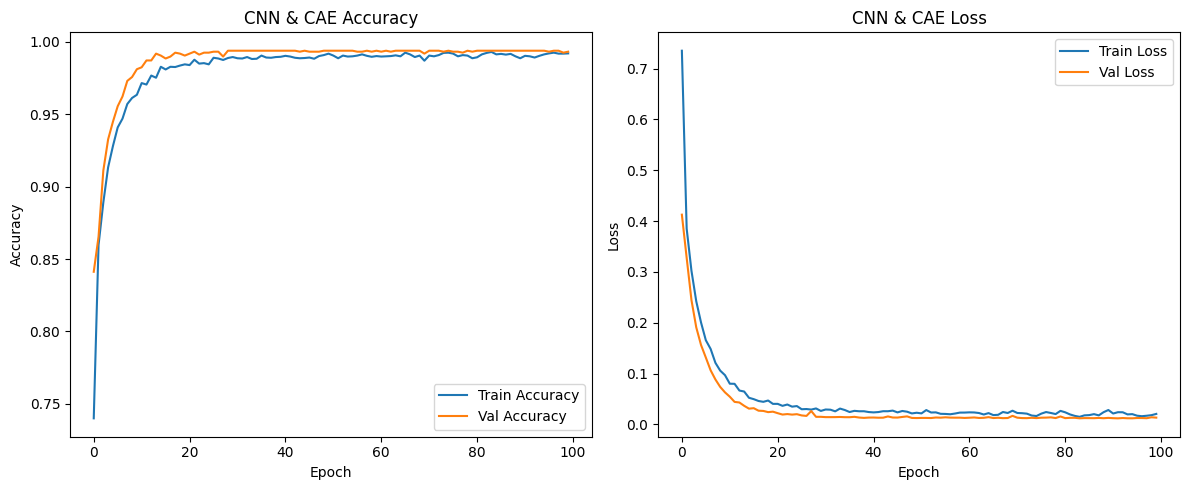



================== CONFUSION MATRIX =====================


<Figure size 1000x800 with 0 Axes>

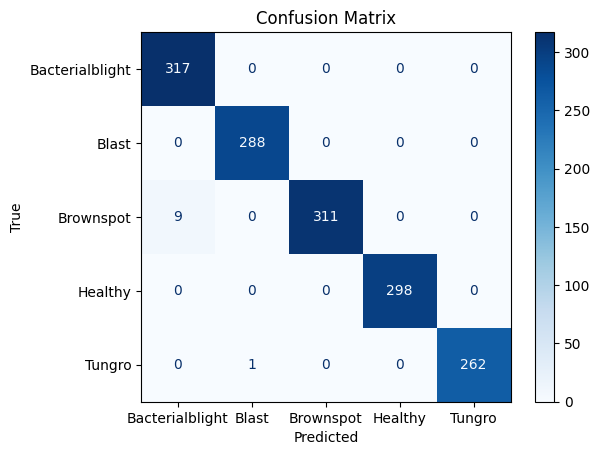



================== CLASSIFICATION REPORT =====================
                 precision    recall  f1-score   support

Bacterialblight       0.97      1.00      0.99       317
          Blast       1.00      1.00      1.00       288
      Brownspot       1.00      0.97      0.99       320
        Healthy       1.00      1.00      1.00       298
         Tungro       1.00      1.00      1.00       263

       accuracy                           0.99      1486
      macro avg       0.99      0.99      0.99      1486
   weighted avg       0.99      0.99      0.99      1486



================== VISUALISASI PREDIKSI =====================


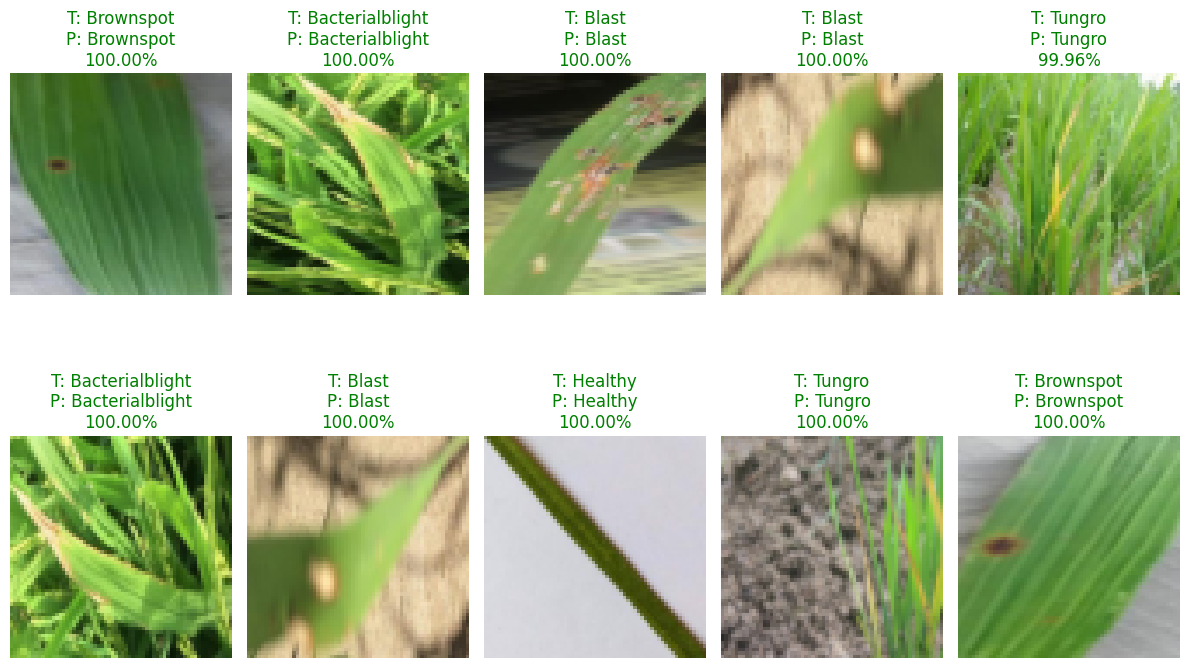

(array([1, 2, 2, ..., 4, 1, 0], dtype=int64),
 array([1, 2, 2, ..., 4, 1, 0], dtype=int64),
 array([[1.42945293e-16, 1.00000000e+00, 9.89599367e-14, 1.25384095e-15,
         6.25409657e-15],
        [2.52845075e-06, 7.49689661e-08, 9.99997377e-01, 1.13238618e-09,
         4.14255887e-11],
        [1.12938725e-08, 7.24392906e-02, 9.27532256e-01, 1.04656912e-07,
         2.83628524e-05],
        ...,
        [2.49418467e-18, 2.32762712e-10, 1.30893537e-16, 1.17868688e-17,
         1.00000000e+00],
        [7.80263187e-10, 1.00000000e+00, 4.93555722e-16, 3.53982685e-12,
         1.03932011e-11],
        [9.99964356e-01, 3.56805685e-05, 2.10721935e-12, 1.14455546e-11,
         4.70193821e-18]], dtype=float32))

In [13]:
print("\n\n================== EVALUASI =====================")
evaluate_model(classifier, x_test, y_test, class_names, encoder=encoder, history=history_classifier, model_name="CNN & CAE")



================== PREDIKSI =====================
1/1 [==============================] - 0s 26ms/step


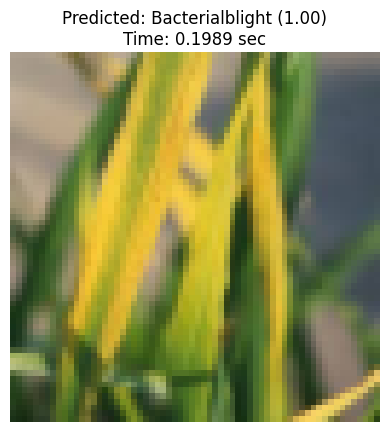

('Bacterialblight', 0.9998752, 0.19889259338378906)

In [14]:
print("\n\n================== PREDIKSI =====================")
predict_single_image(classifier, r'C:\Users\ACER\Downloads\rice\tungro.jpeg', class_names, encoder=encoder)

# DENSENET 201

In [15]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import GlobalAveragePooling2D

def densenet_model(input_shape=(64, 64, 3), n_classes=5):
    base_model = DenseNet201(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    output = Dense(n_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("\n=== DENSENET SUMMARY ===")
    model.summary()

    return model

In [16]:
denseNet201 = densenet_model()
print("\n\n================== DENSENET TRAINING =====================")
history_densenet = denseNet201.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, y_test)
)


=== DENSENET SUMMARY ===
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 70, 70, 3)            0         ['input_2[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv1/conv (Conv2D)         (None, 32, 32, 64)           9408      ['zero_padding2d[0][0]']      
                                                                                                  
 conv1/bn (BatchNormalizati  (None, 32, 32, 64)           256       



================== EVALUASI =====================


================== EVALUASI HASIL EVALUASI =====================
Test Accuracy (from evaluate): 0.9886
Test Loss: 0.0209
47/47 [==============================] - 11s 166ms/step


================== EVALUASI WAKTU =====================
Total prediction time: 10.8764s
Per sample: 0.007319s
Test Accuracy (manual): 98.86%


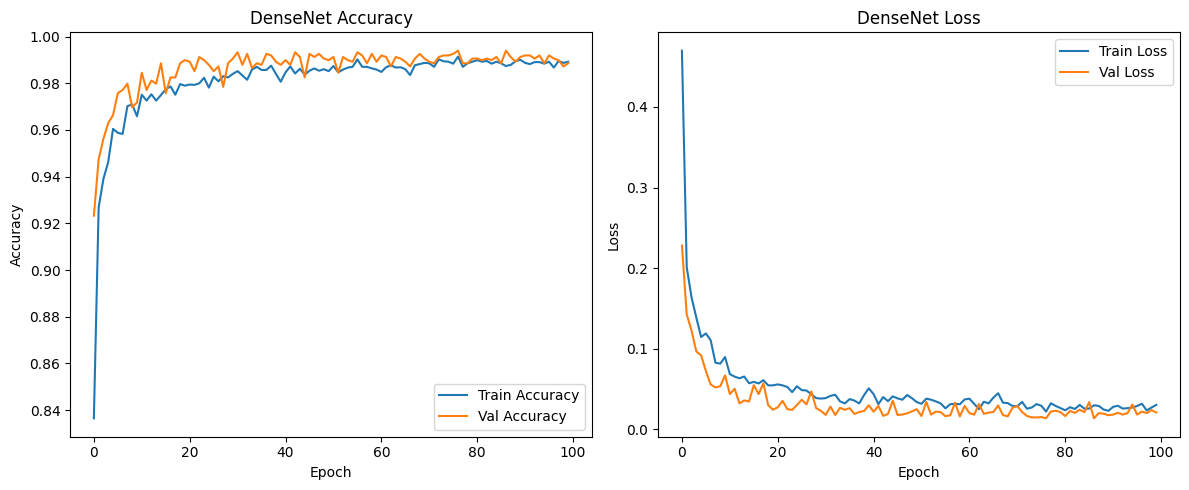



================== CONFUSION MATRIX =====================


<Figure size 1000x800 with 0 Axes>

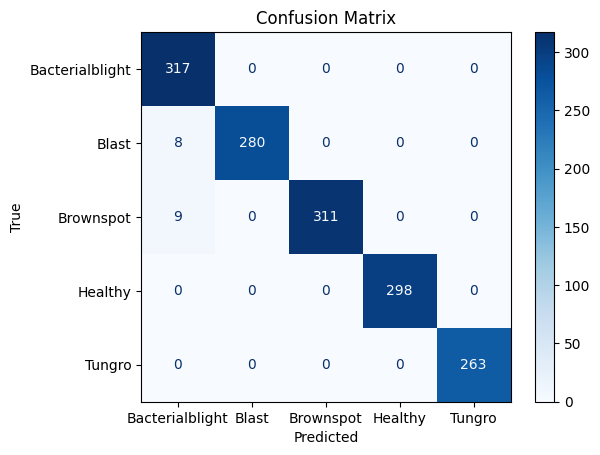



================== CLASSIFICATION REPORT =====================
                 precision    recall  f1-score   support

Bacterialblight       0.95      1.00      0.97       317
          Blast       1.00      0.97      0.99       288
      Brownspot       1.00      0.97      0.99       320
        Healthy       1.00      1.00      1.00       298
         Tungro       1.00      1.00      1.00       263

       accuracy                           0.99      1486
      macro avg       0.99      0.99      0.99      1486
   weighted avg       0.99      0.99      0.99      1486



================== VISUALISASI PREDIKSI =====================


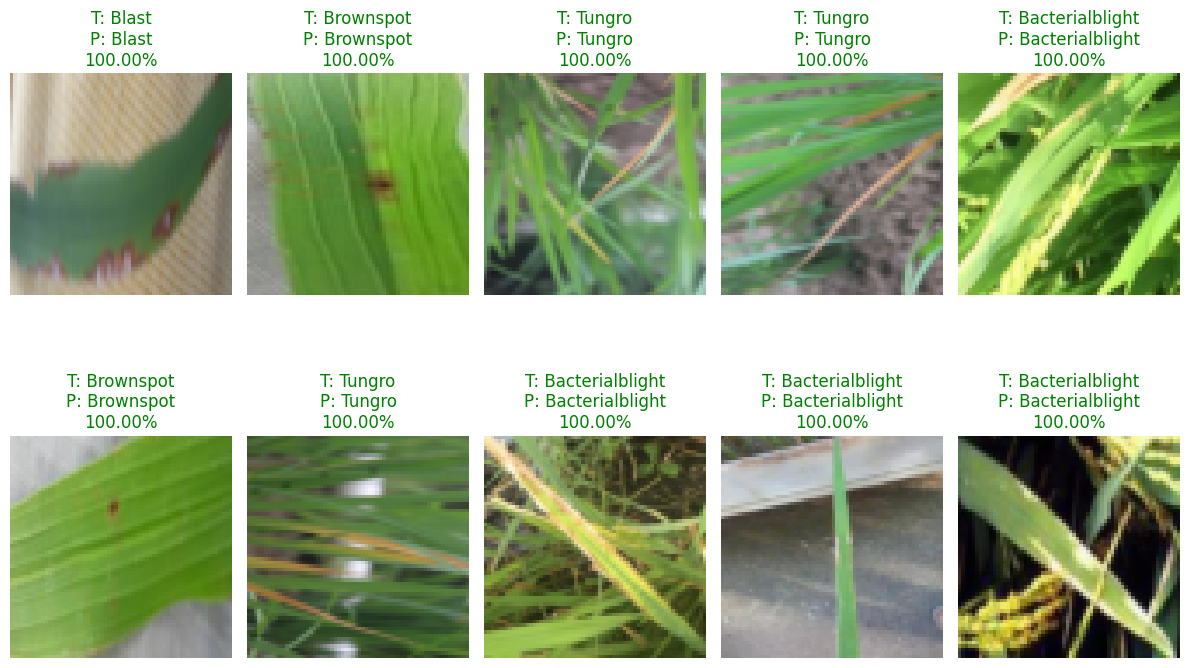

(array([1, 2, 2, ..., 4, 1, 0], dtype=int64),
 array([1, 2, 2, ..., 4, 0, 0], dtype=int64),
 array([[5.3630465e-06, 9.9999464e-01, 2.6623357e-09, 7.4469599e-14,
         9.8436125e-13],
        [8.2101964e-12, 2.7348187e-12, 1.0000000e+00, 2.4873948e-15,
         6.3634989e-15],
        [1.5120806e-06, 1.9388782e-08, 9.9999845e-01, 3.4995958e-12,
         7.5176652e-16],
        ...,
        [7.0345107e-16, 3.7727325e-14, 1.4069310e-17, 3.4282762e-19,
         1.0000000e+00],
        [9.5647389e-01, 4.3511812e-02, 1.4247279e-05, 7.4120948e-08,
         6.6700068e-09],
        [1.0000000e+00, 3.8872876e-08, 2.2010445e-09, 6.2360030e-19,
         9.9070890e-16]], dtype=float32))

In [17]:
print("\n\n================== EVALUASI =====================")
evaluate_model(denseNet201, x_test, y_test, class_names, history=history_densenet, model_name="DenseNet")



================== PREDIKSI =====================
1/1 [==============================] - 0s 201ms/step


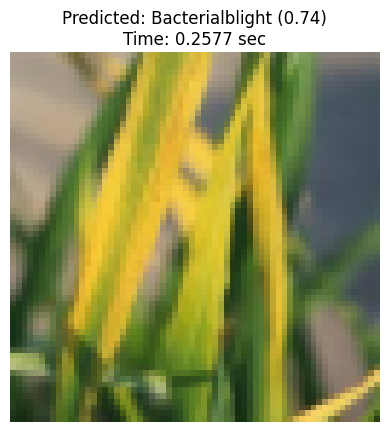

('Bacterialblight', 0.74118656, 0.2577247619628906)

In [18]:
print("\n\n================== PREDIKSI =====================")
predict_single_image(denseNet201, r'C:\Users\ACER\Downloads\rice\tungro.jpeg', class_names)

# CAE+CNN Model 2

In [19]:
def build_autoencoder2(input_shape=(64, 64, 3)):
    input_img = Input(shape=input_shape)

    x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = GlobalMaxPooling2D()(x)
    encoded2 = Dense(128, activation='relu', name='encoded_vector')(x)

    x = Reshape((1, 1, 128))(encoded2)
    x = UpSampling2D((8, 8))(x)
    x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded2 = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder2 = Model(input_img, decoded2, name='Autoencoder')
    encoder2 = Model(inputs=input_img, outputs=encoded2, name='Encoder')

    autoencoder2.compile(optimizer='adam', loss='mse')

    print("\n\n================== AUTOENCODER SUMMARY =====================")
    autoencoder2.summary()

    return autoencoder2, encoder2

In [20]:
def build_cnn_classifier2(input_dim, num_classes):
    model = Sequential(name='CNN_Classifier')
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("\n\n================== CNN SUMMARY =====================")
    model.summary()

    return model

In [21]:
autoencoder2, encoder2 = build_autoencoder2(input_shape=(64, 64, 3))
print("\n\n================== AUTOENCODER TRAINING =====================")
history_autoencoder2 = autoencoder2.fit(
    datagen.flow(x_train, x_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, x_test)
)

print("\n\n================== EKSTRAK ENCODER =====================")
encoded_train2 = encoder2.predict(x_train)
encoded_test2 = encoder2.predict(x_test)



================== AUTOENCODER SUMMARY =====================
Model: "Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 separable_conv2d (Separabl  (None, 64, 64, 32)        155       
 eConv2D)                                                        
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 32, 32, 32)        0         
 g2D)                                                            
                                                                 
 separable_conv2d_1 (Separa  (None, 32, 32, 64)        2400      
 bleConv2D)                                                      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 16, 16, 64)        0  

In [22]:
classifier2 = build_cnn_classifier2(input_dim=128, num_classes=N_CLASSES)
print("\n\n================== CNN TRAINING =====================")
history_classifier2 = classifier2.fit(
    encoded_train2, y_train,
    epochs=EPOCHS,
    validation_data=(encoded_test2, y_test)
)



================== CNN SUMMARY =====================
Model: "CNN_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 128)               16512     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 5)                 325       
                                                                 
Total params: 25093 (98.02 KB)
Trainable params: 25093 (98.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


================== CNN TRAINING =====================
Epoch 1/100
186/186 [================



================== EVALUASI =====================
47/47 [==============================] - 0s 8ms/step


================== EVALUASI HASIL EVALUASI =====================
Test Accuracy (from evaluate): 0.9899
Test Loss: 0.0207
47/47 [==============================] - 0s 1ms/step


================== EVALUASI WAKTU =====================
Total prediction time: 0.1702s
Per sample: 0.000115s
Test Accuracy (manual): 98.99%


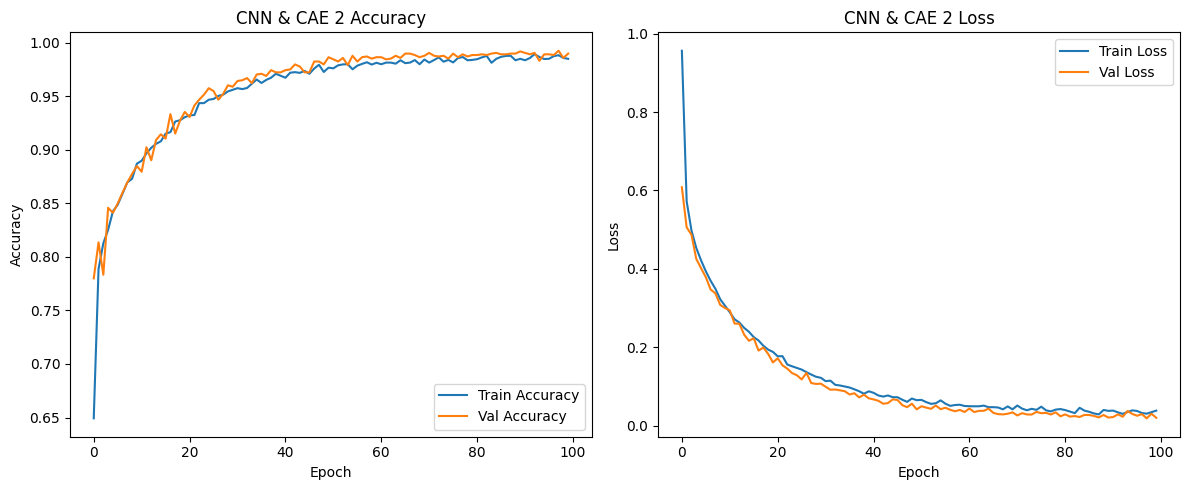



================== CONFUSION MATRIX =====================


<Figure size 1000x800 with 0 Axes>

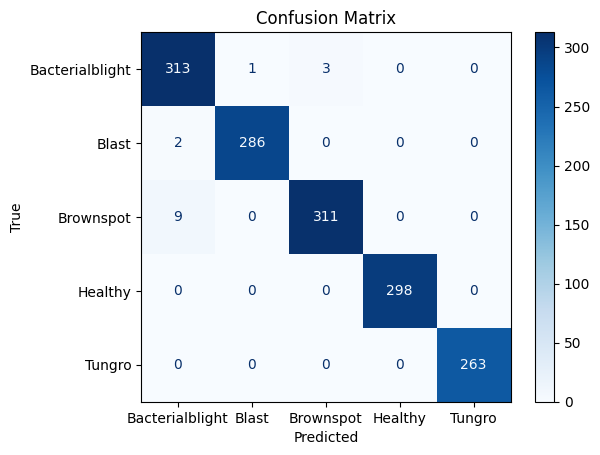



================== CLASSIFICATION REPORT =====================
                 precision    recall  f1-score   support

Bacterialblight       0.97      0.99      0.98       317
          Blast       1.00      0.99      0.99       288
      Brownspot       0.99      0.97      0.98       320
        Healthy       1.00      1.00      1.00       298
         Tungro       1.00      1.00      1.00       263

       accuracy                           0.99      1486
      macro avg       0.99      0.99      0.99      1486
   weighted avg       0.99      0.99      0.99      1486



================== VISUALISASI PREDIKSI =====================


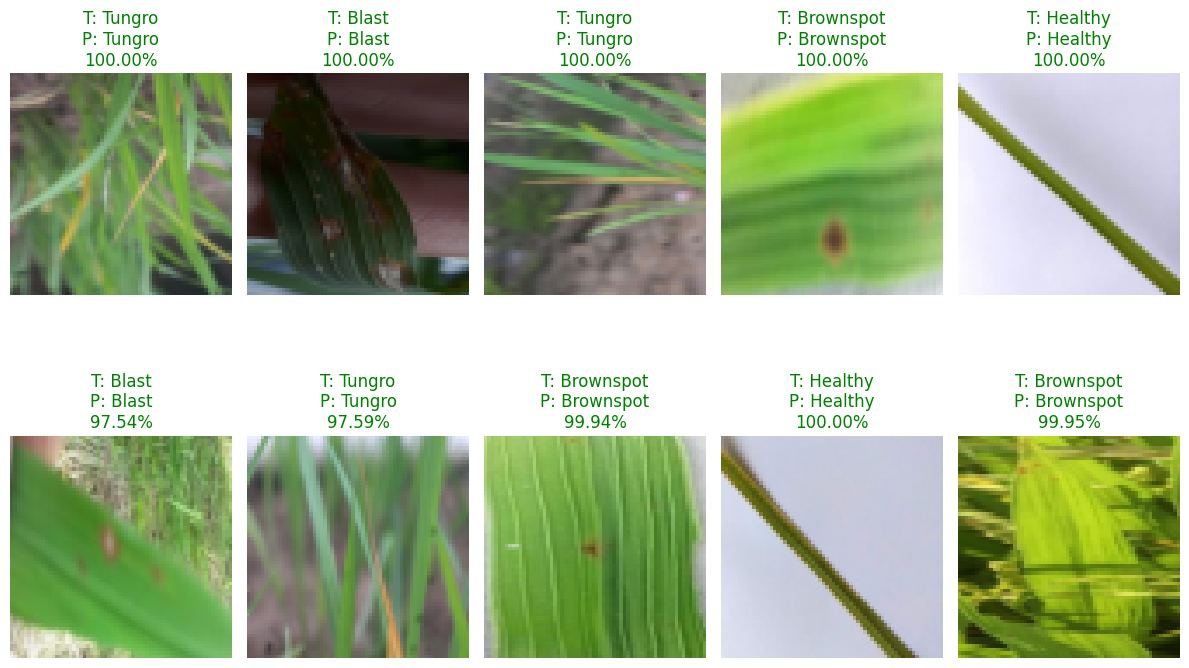

(array([1, 2, 2, ..., 4, 1, 0], dtype=int64),
 array([1, 2, 2, ..., 4, 1, 0], dtype=int64),
 array([[5.05612297e-06, 9.99971628e-01, 2.33389746e-05, 5.17614685e-14,
         1.27456693e-13],
        [4.62241583e-02, 6.33914839e-04, 9.53141093e-01, 6.97111432e-07,
         1.61579720e-07],
        [2.22937047e-07, 3.54503915e-02, 9.64242935e-01, 5.62876204e-11,
         3.06428759e-04],
        ...,
        [7.16219792e-11, 2.99926994e-13, 1.02556082e-12, 1.68461774e-21,
         1.00000000e+00],
        [5.96777209e-05, 9.99918222e-01, 2.20042020e-05, 9.75368744e-11,
         9.14941438e-08],
        [9.99888539e-01, 1.11307156e-04, 6.26816871e-12, 1.74410332e-07,
         5.35368191e-20]], dtype=float32))

In [23]:
print("\n\n================== EVALUASI =====================")
evaluate_model(classifier2, x_test, y_test, class_names, encoder=encoder2, history=history_classifier2, model_name="CNN & CAE 2")



================== PREDIKSI =====================
1/1 [==============================] - 0s 17ms/step


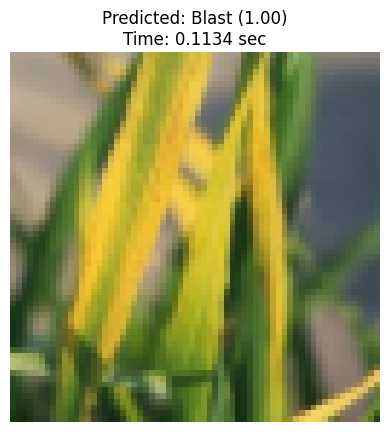

('Blast', 0.9996728, 0.11338257789611816)

In [24]:
print("\n\n================== PREDIKSI =====================")
predict_single_image(classifier2, r'C:\Users\ACER\Downloads\rice\tungro.jpeg', class_names, encoder=encoder2)

# CAE+CNN Model 3

In [9]:
def se_block(input_tensor, reduction=16):
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se = GlobalMaxPooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // reduction, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    x = Multiply()([input_tensor, se])
    return x

In [15]:
def build_autoencoder3(input_shape=(64, 64, 3)):
    input_img = Input(shape=input_shape)

    x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = se_block(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = se_block(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = se_block(x)
    x = MaxPooling2D((2, 2), padding='same')(x)

    x = GlobalMaxPooling2D()(x)
    encoded3 = Dense(128, activation='relu', name='encoded_vector')(x)

    x = Reshape((1, 1, 128))(encoded3)
    x = UpSampling2D((8, 8))(x)
    x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded3 = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder3 = Model(input_img, decoded3, name='Autoencoder')
    encoder3 = Model(inputs=input_img, outputs=encoded3, name='Encoder')

    autoencoder3.compile(optimizer='adam', loss='mse')

    print("\n\n================== AUTOENCODER SUMMARY =====================")
    autoencoder3.summary()

    return autoencoder3, encoder3

In [34]:
def build_cnn_classifier3(input_dim, num_classes):
    model = Sequential(name='CNN_Classifier')
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    Dropout(0.3),
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("\n\n================== CNN SUMMARY =====================")
    model.summary()

    return model

In [35]:
autoencoder3, encoder3 = build_autoencoder3(input_shape=(64, 64, 3))
print("\n\n================== AUTOENCODER TRAINING =====================")
history_autoencoder3 = autoencoder3.fit(
    datagen.flow(x_train, x_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(x_test, x_test)
)

print("\n\n================== EKSTRAK ENCODER =====================")
encoded_train3 = encoder3.predict(x_train)
encoded_test3 = encoder3.predict(x_test)



================== AUTOENCODER SUMMARY =====================
Model: "Autoencoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 separable_conv2d_12 (Separ  (None, 64, 64, 32)           155       ['input_5[0][0]']             
 ableConv2D)                                                                                      
                                                                                                  
 global_max_pooling2d_6 (Gl  (None, 32)                   0         ['separable_conv2d_12[0][0]'] 
 obalMaxPooling2D)                                                                                
                         

In [36]:
classifier3 = build_cnn_classifier3(input_dim=128, num_classes=N_CLASSES)
print("\n\n================== CNN TRAINING =====================")
history_classifier3 = classifier3.fit(
    encoded_train3, y_train,
    epochs=EPOCHS,
    validation_data=(encoded_test3, y_test)
)



================== CNN SUMMARY =====================
Model: "CNN_Classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_26 (Dense)            (None, 128)               16512     
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 dense_27 (Dense)            (None, 64)                8256      
                                                                 
 dense_28 (Dense)            (None, 5)                 325       
                                                                 
Total params: 25093 (98.02 KB)
Trainable params: 25093 (98.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


================== CNN TRAINING =====================
Epoch 1/100
186/186 [================



================== EVALUASI =====================
47/47 [==============================] - 1s 11ms/step


================== EVALUASI HASIL EVALUASI =====================
Test Accuracy (from evaluate): 0.9906
Test Loss: 0.0262
47/47 [==============================] - 0s 1ms/step


================== EVALUASI WAKTU =====================
Total prediction time: 0.2039s
Per sample: 0.000137s
Test Accuracy (manual): 99.06%


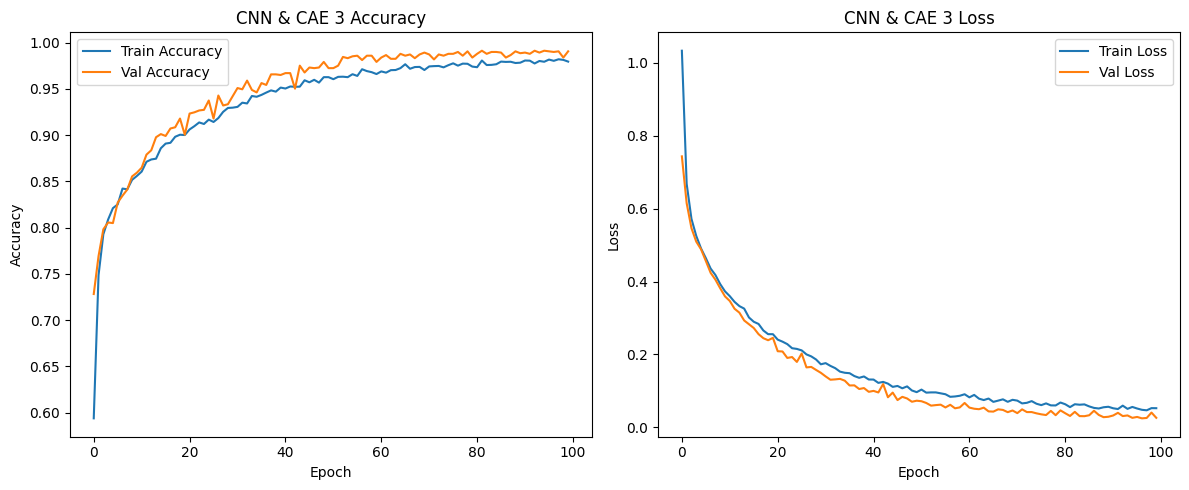



================== CONFUSION MATRIX =====================


<Figure size 1000x800 with 0 Axes>

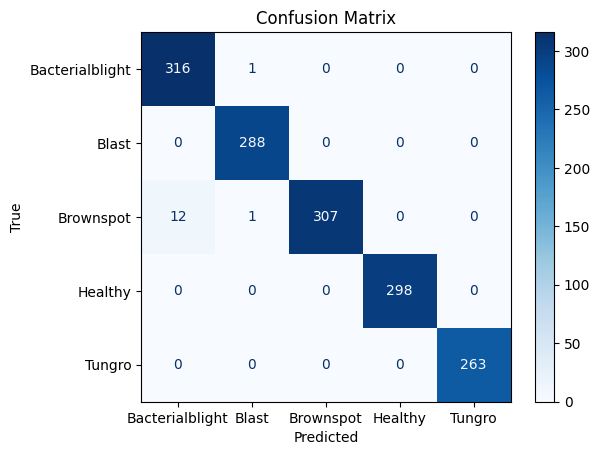



================== CLASSIFICATION REPORT =====================
                 precision    recall  f1-score   support

Bacterialblight       0.96      1.00      0.98       317
          Blast       0.99      1.00      1.00       288
      Brownspot       1.00      0.96      0.98       320
        Healthy       1.00      1.00      1.00       298
         Tungro       1.00      1.00      1.00       263

       accuracy                           0.99      1486
      macro avg       0.99      0.99      0.99      1486
   weighted avg       0.99      0.99      0.99      1486



================== VISUALISASI PREDIKSI =====================


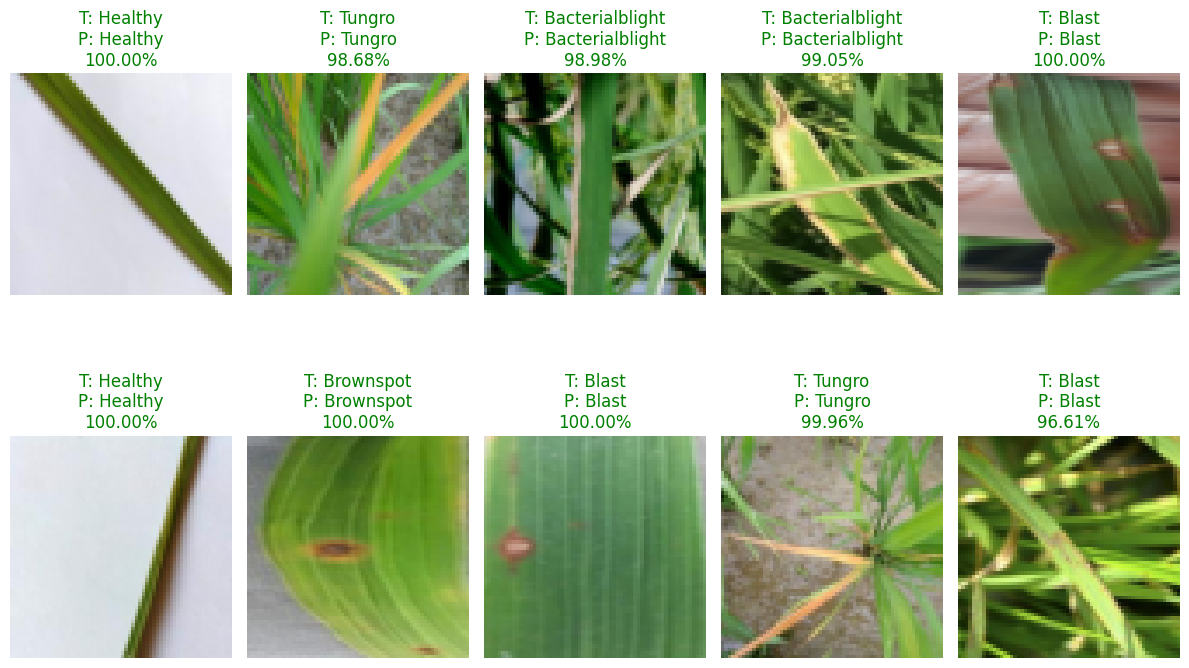

(array([1, 2, 2, ..., 4, 1, 0], dtype=int64),
 array([1, 2, 2, ..., 4, 1, 0], dtype=int64),
 array([[2.2621531e-09, 9.9612731e-01, 3.8727671e-03, 1.6504532e-12,
         5.3948571e-17],
        [7.1506416e-03, 1.2380228e-06, 9.9284691e-01, 1.2174954e-06,
         1.0944104e-12],
        [1.9654401e-06, 3.9139464e-03, 9.9608141e-01, 5.5355574e-11,
         2.6994021e-06],
        ...,
        [1.5521302e-08, 6.0996129e-08, 3.9931869e-12, 8.8643685e-18,
         9.9999988e-01],
        [1.2476373e-03, 9.9855834e-01, 1.9398342e-04, 1.4013007e-09,
         1.1125436e-11],
        [9.9977392e-01, 2.2609590e-04, 6.6960543e-16, 2.5751534e-10,
         3.4868536e-22]], dtype=float32))

In [37]:
print("\n\n================== EVALUASI =====================")
evaluate_model(classifier3, x_test, y_test, class_names, encoder=encoder3, history=history_classifier3, model_name="CNN & CAE 3")



================== PREDIKSI =====================
1/1 [==============================] - 0s 28ms/step


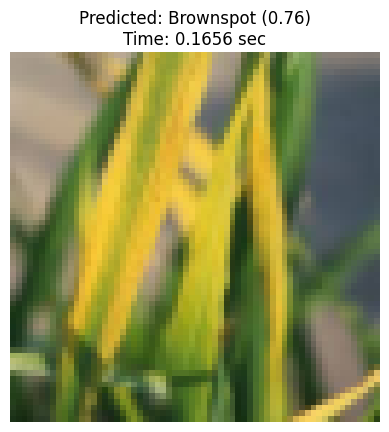

('Brownspot', 0.75883543, 0.16555476188659668)

In [38]:
print("\n\n================== PREDIKSI =====================")
predict_single_image(classifier3, r'C:\Users\ACER\Downloads\rice\tungro.jpeg', class_names, encoder=encoder3)

# SISA

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, SeparableConv2D, MaxPooling2D, UpSampling2D,
                                     GlobalMaxPooling2D, Dense, Reshape, Conv2D)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
input_img = Input(shape=(64, 64, 3))

x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = GlobalMaxPooling2D()(x)
encoded2 = Dense(128, activation='relu', name='encoded_vector')(x)

x = Reshape((1, 1, 128))(encoded2)
x = UpSampling2D((8, 8))(x)
x = SeparableConv2D(128, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = SeparableConv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded2 = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder2 = Model(input_img, decoded2)
autoencoder2.compile(optimizer='adam', loss='mse')

In [ ]:
autoencoder2.fit(
    datagen.flow(x_train, x_train, batch_size=64),
    epochs=100,
    validation_data=(x_test, x_test)
)

In [ ]:
encoder2 = Model(inputs=input_img, outputs=encoded2)
encoded_train2 = encoder2.predict(x_train)
encoded_test2 = encoder2.predict(x_test)

In [ ]:
CaeCnn2 = Sequential([
    Dense(128, activation='relu', input_shape=(128,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(nClass, activation='softmax')
])

CaeCnn2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_caeCnn2 = CaeCnn2.fit(encoded_train2, y_train, epochs=100, validation_data=(encoded_test2, y_test))

In [ ]:
print(autoencoder2.summary())

In [ ]:
print(CaeCnn2.summary())

In [ ]:
import time

start_time = time.time()

encoded_test2 = encoder2.predict(x_test)
y_pred_probs = CaeCnn2.predict(encoded_test2)
y_pred = np.argmax(y_pred_probs, axis=1)

end_time = time.time()

y_true = np.argmax(y_test, axis=1)

total_time = end_time - start_time
time_per_sample = total_time / len(x_test)
accuracy_all = np.mean(y_pred == y_true) * 100

print(f"\n=== Testing Time Result ===")
print(f"Total time for testing: {total_time:.4f} seconds")
print(f"Average time per sample: {time_per_sample:.4f} seconds")
print(f"Accuracy on all test samples: {accuracy_all:.4f}%")


In [ ]:
single_image = x_test[0:1]
true_label_single = y_true[0]

start_time = time.time()
encoded_single2 = encoder2.predict(single_image)
pred_single = CaeCnn2.predict(encoded_single2)
pred_label_single = np.argmax(pred_single)
end_time = time.time()

accuracy_single = int(pred_label_single == true_label_single) * 100

print(f"\n=== Single Image Prediction ===")
print(f"Time for single image prediction: {end_time - start_time:.6f} seconds")
print(f"Predicted label: {pred_label_single}")
print(f"True label: {true_label_single}")
print(f"Accuracy for single image: {accuracy_single:.2f}%")

In [ ]:
test_loss, test_acc = CaeCnn2.evaluate(encoded_test2, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_caeCnn2.history['accuracy'], label='Train Accuracy')
plt.plot(history_caeCnn2.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN & CAE Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_caeCnn2.history['loss'], label='Train Loss')
plt.plot(history_caeCnn2.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN & CAE Loss')
plt.legend()

plt.tight_layout()
plt.show()

y_pred = np.argmax(CaeCnn2.predict(encoded_test2), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=valid_class_names))

In [ ]:
def visualize_predictions(images, y_true, y_pred, class_names, confidences, num_images=10):
    random_indices = random.sample(range(len(images)), num_images)
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(random_indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[idx])
        plt.axis('off')
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = confidences[idx] * 100
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"T: {true_label}\nP: {pred_label}\n{confidence:.2f}%", color=color)
    plt.tight_layout()
    plt.show()


y_pred_probs = CaeCnn2.predict(encoded_test2)
y_pred = np.argmax(y_pred_probs, axis=1)
confidences = np.max(y_pred_probs, axis=1)

visualize_predictions(x_test, y_true, y_pred, valid_class_names, confidences)


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class_names = valid_class_names 

def load_and_preprocess_image(img_path, target_size=(64, 64)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0) 
    return img_array

img_path = "/content/drive/MyDrive/Colab_Notebooks/Rice-Leaf-Disease-Images/brownspot.jpg"
img_array = load_and_preprocess_image(img_path)

encoded_img = encoder2.predict(img_array)
prediction = CaeCnn2.predict(encoded_img)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

predicted_label = class_names[predicted_class]

print("Predicted class:", predicted_label)
print("Confidence:", confidence)

plt.imshow(img_array[0])
plt.title(f"Predicted: {predicted_label}, Confidence: {confidence:.2f}")
plt.axis('off')
plt.show()


## CAE+CNN+SE BLOCK


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, SeparableConv2D, MaxPooling2D, UpSampling2D,
                                     GlobalMaxPooling2D, Dense, Reshape, Conv2D)
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Reshape, Multiply

def se_block(input_tensor, reduction=16):
    channel_axis = -1
    filters = input_tensor.shape[channel_axis]

    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, filters))(se)
    se = Dense(filters // reduction, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    x = Multiply()([input_tensor, se])
    return x


In [ ]:

input_img = Input(shape=(64, 64, 3))

x = SeparableConv2D(8, (3, 3), activation='relu', padding='same')(input_img)
x = se_block(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = SeparableConv2D(16, (3, 3), activation='relu', padding='same')(x)
x = se_block(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(x)
x = se_block(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = GlobalMaxPooling2D()(x)
encoded3 = Dense(32, activation='relu', name='encoded_vector')(x)

x = Reshape((1, 1, 32))(encoded3)
x = UpSampling2D((8, 8))(x)
x = SeparableConv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = SeparableConv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = SeparableConv2D(8, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded3 = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder3 = Model(input_img, decoded3)
autoencoder3.compile(optimizer='adam', loss='mse')

In [ ]:
autoencoder3.fit(
    datagen.flow(x_train, x_train, batch_size=64),
    epochs=100,
    validation_data=(x_test, x_test)
)

In [ ]:
encoder3 = Model(inputs=input_img, outputs=encoded3)
encoded_train3 = encoder3.predict(x_train)
encoded_test3 = encoder3.predict(x_test)

In [ ]:
CaeCnn3 = Sequential([
    Dense(32, activation='relu', input_shape=(32,)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(nClass, activation='softmax')
])

CaeCnn3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_caeCnn3 = CaeCnn3.fit(encoded_train3, y_train, epochs=100, validation_data=(encoded_test3, y_test))

In [ ]:
print(autoencoder3.summary())

In [ ]:
print(CaeCnn3.summary())

In [ ]:
import time

start_time = time.time()

encoded_test3 = encoder3.predict(x_test)
y_pred_probs = CaeCnn3.predict(encoded_test3)
y_pred = np.argmax(y_pred_probs, axis=1)

end_time = time.time()

y_true = np.argmax(y_test, axis=1)

total_time = end_time - start_time
time_per_sample = total_time / len(x_test)
accuracy_all = np.mean(y_pred == y_true) * 100

print(f"\n=== Testing Time Result ===")
print(f"Total time for testing: {total_time:.4f} seconds")
print(f"Average time per sample: {time_per_sample:.4f} seconds")
print(f"Accuracy on all test samples: {accuracy_all:.4f}%")


In [ ]:
single_image = x_test[0:1]
true_label_single = y_true[0]

start_time = time.time()
encoded_single3 = encoder3.predict(single_image)
pred_single = CaeCnn3.predict(encoded_single3)
pred_label_single = np.argmax(pred_single)
end_time = time.time()

accuracy_single = int(pred_label_single == true_label_single) * 100

print(f"\n=== Single Image Prediction ===")
print(f"Time for single image prediction: {end_time - start_time:.6f} seconds")
print(f"Predicted label: {pred_label_single}")
print(f"True label: {true_label_single}")
print(f"Accuracy for single image: {accuracy_single:.2f}%")

In [ ]:
test_loss, test_acc = CaeCnn3.evaluate(encoded_test3, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_caeCnn3.history['accuracy'], label='Train Accuracy')
plt.plot(history_caeCnn3.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN & CAE Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_caeCnn3.history['loss'], label='Train Loss')
plt.plot(history_caeCnn3.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN & CAE Loss')
plt.legend()

plt.tight_layout()
plt.show()

y_pred = np.argmax(CaeCnn3.predict(encoded_test3), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=valid_class_names))

In [ ]:
def visualize_predictions(images, y_true, y_pred, class_names, confidences, num_images=10):
    random_indices = random.sample(range(len(images)), num_images)
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(random_indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[idx])
        plt.axis('off')
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = confidences[idx] * 100
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"T: {true_label}\nP: {pred_label}\n{confidence:.2f}%", color=color)
    plt.tight_layout()
    plt.show()


y_pred_probs = CaeCnn3.predict(encoded_test3)
y_pred = np.argmax(y_pred_probs, axis=1)
confidences = np.max(y_pred_probs, axis=1)

visualize_predictions(x_test, y_true, y_pred, valid_class_names, confidences)


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

class_names = valid_class_names 

def load_and_preprocess_image(img_path, target_size=(64, 64)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0) 
    return img_array

img_path = "/content/drive/MyDrive/Colab_Notebooks/Rice-Leaf-Disease-Images/brownspot.jpg"
img_array = load_and_preprocess_image(img_path)

encoded_img = encoder3.predict(img_array)
prediction = CaeCnn3.predict(encoded_img)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

predicted_label = class_names[predicted_class]

print("Predicted class:", predicted_label)
print("Confidence:", confidence)

plt.imshow(img_array[0])
plt.title(f"Predicted: {predicted_label}, Confidence: {confidence:.2f}")
plt.axis('off')
plt.show()


### CNN

In [ ]:
cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(nClass, activation='softmax')
])

cnn.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_cnn = cnn.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=100,
    validation_data=(x_test, y_test)
)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.5031 - loss: 1.1746 - val_accuracy: 0.7925 - val_loss: 0.5486
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.7722 - loss: 0.5869 - val_accuracy: 0.8247 - val_loss: 0.3790
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.8264 - loss: 0.4528 - val_accuracy: 0.8570 - val_loss: 0.3105
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.8686 - loss: 0.3329 - val_accuracy: 0.8885 - val_loss: 0.2590
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.8929 - loss: 0.2706 - val_accuracy: 0.8536 - val_loss: 0.3333
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8849 - loss: 0.2859 - val_accuracy: 0.9315 - val_loss: 0.1619
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9218 - loss: 0.2058 - val_accuracy: 0.9140 - val_loss: 0.2121
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9314 - loss: 0.1746 - val_accuracy: 0.9396 - va

In [ ]:
import time

start_time = time.time()

y_pred = np.argmax(cnn.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

end_time = time.time()

total_time = end_time - start_time
time_per_sample = total_time / len(x_test)

accuracy_all = np.mean(y_pred == y_true) * 100

print("\n=== Testing Time Result (All Data) ===")
print(f"Total time for testing: {total_time:.4f} seconds")
print(f"Average time per sample: {time_per_sample:.4f} seconds")
print(f"Accuracy on all test samples: {accuracy_all:.4f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

=== Testing Time Result (All Data) ===
Total time for testing: 1.3826 seconds
Average time per sample: 0.0009 seconds
Accuracy on all test samples: 99.2612%


In [ ]:
single_image = x_test[0:1]
true_label = y_true[0]

start_time = time.time()

pred_single = cnn.predict(single_image)
pred_label = np.argmax(pred_single)

end_time = time.time()

accuracy_single = int(pred_label == true_label)

print("\n=== Single Image Prediction ===")
print(f"Time for single image prediction: {end_time - start_time:.4f} seconds")
print(f"Predicted label: {pred_label}")
print(f"True label: {true_label}")
print(f"Accuracy for single image: {accuracy_single * 100:.4f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step

=== Single Image Prediction ===
Time for single image prediction: 0.3608 seconds
Predicted label: 3
True label: 3
Accuracy for single image: 100.0000%


In [ ]:
print(cnn.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,575,825 (25.08 MB)

 Trainable params: 2,191,941 (8.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,383,884 (16.72 MB)

None


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9913 - loss: 0.0136
Test Accuracy: 0.9926


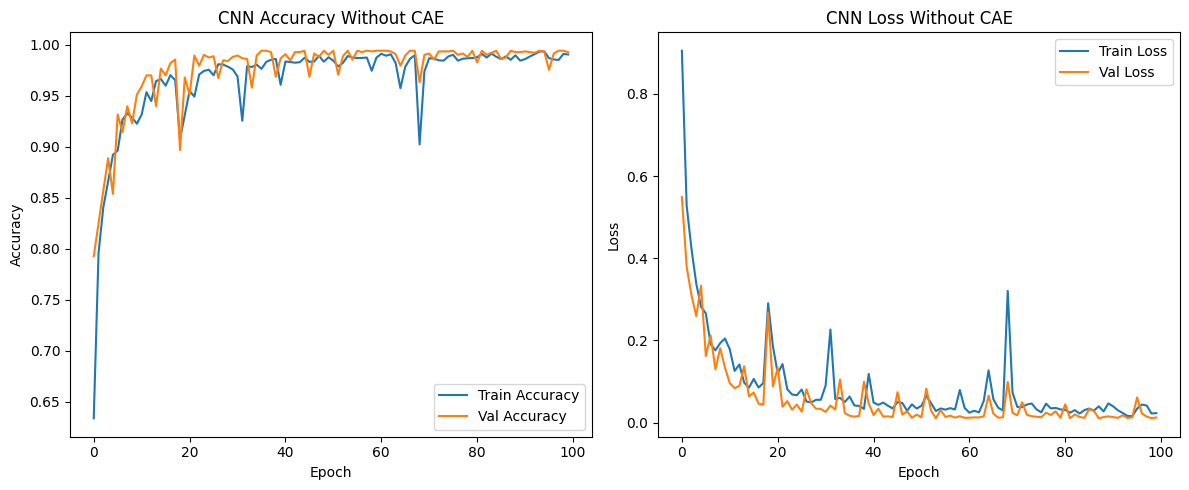

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


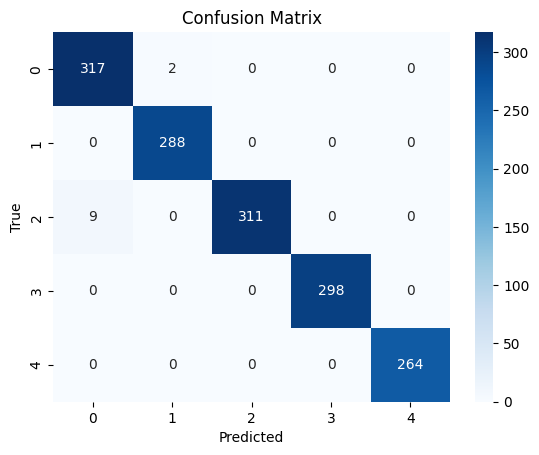

                 precision    recall  f1-score   support

Bacterialblight       0.97      0.99      0.98       319
          Blast       0.99      1.00      1.00       288
      Brownspot       1.00      0.97      0.99       320
        Healthy       1.00      1.00      1.00       298
         Tungro       1.00      1.00      1.00       264

       accuracy                           0.99      1489
      macro avg       0.99      0.99      0.99      1489
   weighted avg       0.99      0.99      0.99      1489



In [ ]:
test_loss, test_acc = cnn.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy Without CAE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss Without CAE')
plt.legend()

plt.tight_layout()
plt.show()

y_pred = np.argmax(cnn.predict(x_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=valid_class_names))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


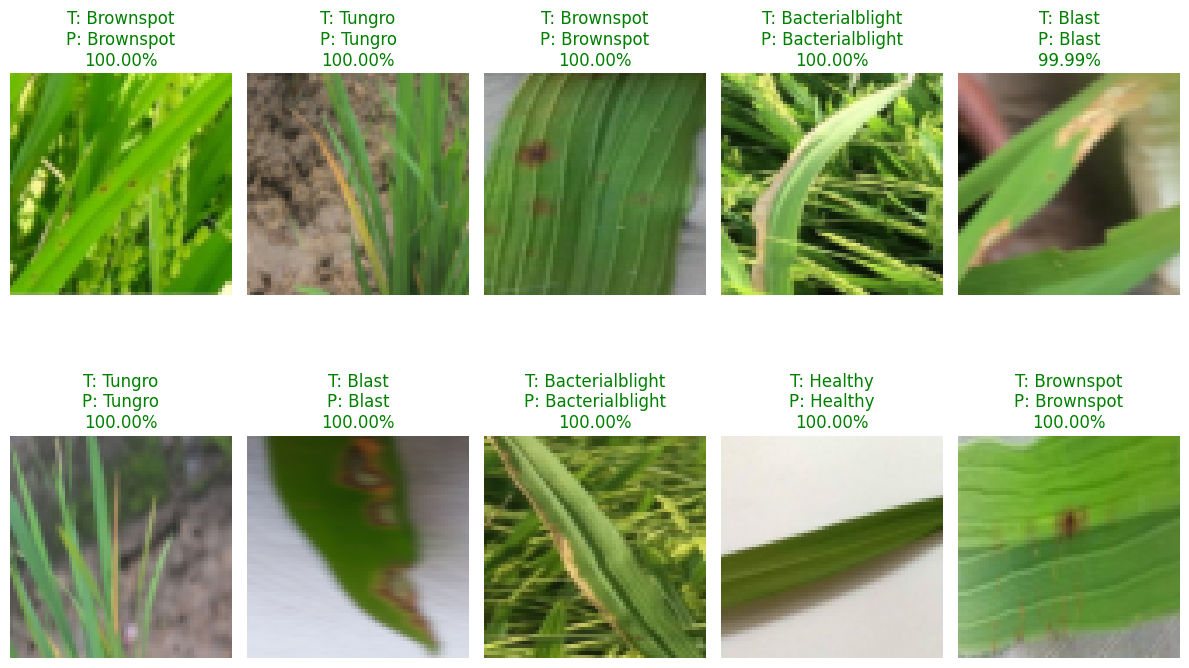

In [ ]:
def visualize_predictions(images, y_true, y_pred, class_names, confidences, num_images=10):
    random_indices = random.sample(range(len(images)), num_images)
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(random_indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[idx])
        plt.axis('off')
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = confidences[idx] * 100
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"T: {true_label}\nP: {pred_label}\n{confidence:.2f}%", color=color)
    plt.tight_layout()
    plt.show()

y_pred_probs = cnn.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
confidences = np.max(y_pred_probs, axis=1)

visualize_predictions(x_test, y_true, y_pred, valid_class_names, confidences)


## DENSENET201


In [ ]:
base_model = DenseNet201(include_top=False, weights='imagenet', input_shape=(64, 64, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(nClass, activation='softmax')(x)

denseNet = Model(inputs=base_model.input, outputs=output)

denseNet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

history_densenet = denseNet.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=100,
    validation_data=(x_test, y_test)
)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


94/94 ━━━━━━━━━━━━━━━━━━━━ 116s 800ms/step - accuracy: 0.7844 - loss: 0.5921 - val_accuracy: 0.9328 - val_loss: 0.1682
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.9481 - loss: 0.1537 - val_accuracy: 0.9731 - val_loss: 0.0956
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9606 - loss: 0.1127 - val_accuracy: 0.9745 - val_loss: 0.0637
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.9721 - loss: 0.0811 - val_accuracy: 0.9772 - val_loss: 0.0824
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9788 - loss: 0.0786 - val_accuracy: 0.9832 - val_loss: 0.0460
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.9767 - loss: 0.0667 - val_accuracy: 0.9852 - val_loss: 0.0405
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.9798 - loss: 0.0536 - val_accuracy: 0.9893 - val_loss: 0.0319
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9806 - loss: 0.0598 - val_accuracy:

In [ ]:
import time
start_time = time.time()

y_pred_probs = denseNet.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

end_time = time.time()
total_time = end_time - start_time
time_per_sample = total_time / len(x_test)
accuracy_all = np.mean(y_pred == y_true) * 100

print("\n=== Testing Time Result (All Data) ===")
print(f"Total time for testing: {total_time:.4f} seconds")
print(f"Average time per sample: {time_per_sample:.4f} seconds")
print(f"Accuracy on all test samples: {accuracy_all:.4f}%")

single_image = x_test[0:1]
true_label = y_true[0]

start_time = time.time()
pred_single = denseNet.predict(single_image)
pred_label = np.argmax(pred_single)
end_time = time.time()

accuracy_single = int(pred_label == true_label)

print("\n=== Single Image Prediction ===")
print(f"Time for single image prediction: {end_time - start_time:.4f} seconds")
print(f"Predicted label: {pred_label}")
print(f"True label: {true_label}")
print(f"Accuracy for single image: {accuracy_single * 100:.4f}%")

47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 467ms/step

=== Testing Time Result (All Data) ===
Total time for testing: 41.2235 seconds
Average time per sample: 0.0277 seconds
Accuracy on all test samples: 99.3956%
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step

=== Single Image Prediction ===
Time for single image prediction: 20.5108 seconds
Predicted label: 3
True label: 3
Accuracy for single image: 100.0000%


In [ ]:
print(denseNet.summary())

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 70, 70, 3) │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 16,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 16, 16,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 16, 16,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 16, 16,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 16, 16,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 16, 16,    │     12,288 │ conv2_block2_0_r

 Total params: 19,801,169 (75.54 MB)

 Trainable params: 493,061 (1.88 MB)

 Non-trainable params: 18,321,984 (69.89 MB)

 Optimizer params: 986,124 (3.76 MB)

None


47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9934 - loss: 0.0108
Test Accuracy: 0.9940


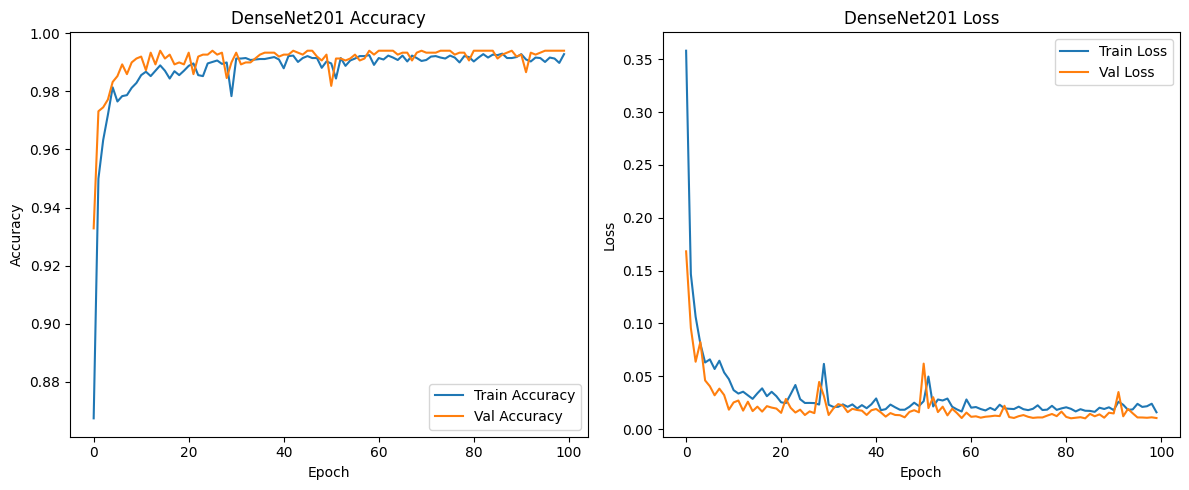

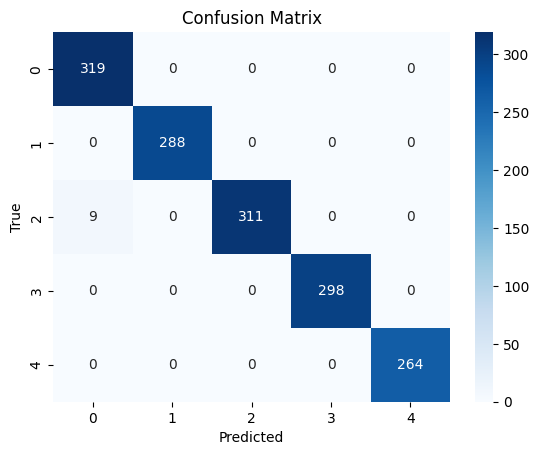

                 precision    recall  f1-score   support

Bacterialblight       0.97      1.00      0.99       319
          Blast       1.00      1.00      1.00       288
      Brownspot       1.00      0.97      0.99       320
        Healthy       1.00      1.00      1.00       298
         Tungro       1.00      1.00      1.00       264

       accuracy                           0.99      1489
      macro avg       0.99      0.99      0.99      1489
   weighted avg       0.99      0.99      0.99      1489



In [ ]:
test_loss, test_acc = denseNet.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_densenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_densenet.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('DenseNet201 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_densenet.history['loss'], label='Train Loss')
plt.plot(history_densenet.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DenseNet201 Loss')
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=valid_class_names))

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


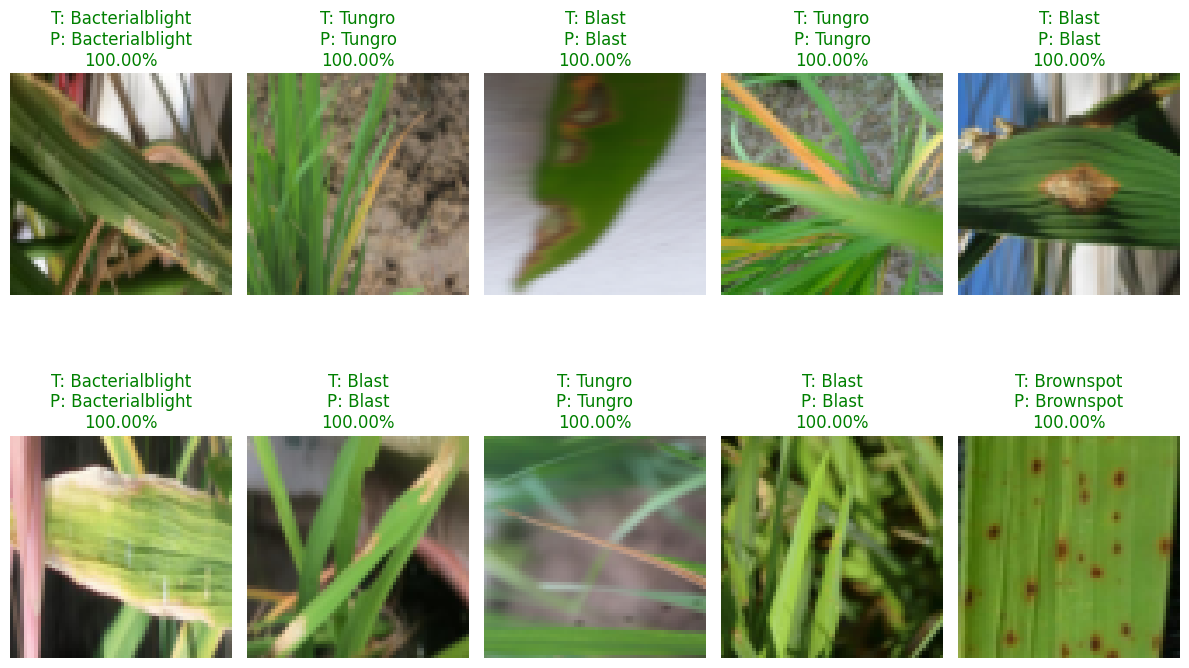

In [ ]:
def visualize_predictions(images, y_true, y_pred, class_names, confidences, num_images=10):
    random_indices = random.sample(range(len(images)), num_images)
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(random_indices):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[idx])
        plt.axis('off')
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        confidence = confidences[idx] * 100
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"T: {true_label}\nP: {pred_label}\n{confidence:.2f}%", color=color)
    plt.tight_layout()
    plt.show()

y_pred_probs = denseNet.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
confidences = np.max(y_pred_probs, axis=1)

visualize_predictions(x_test, y_true, y_pred, valid_class_names, confidences)

### Analisis Perbandingan

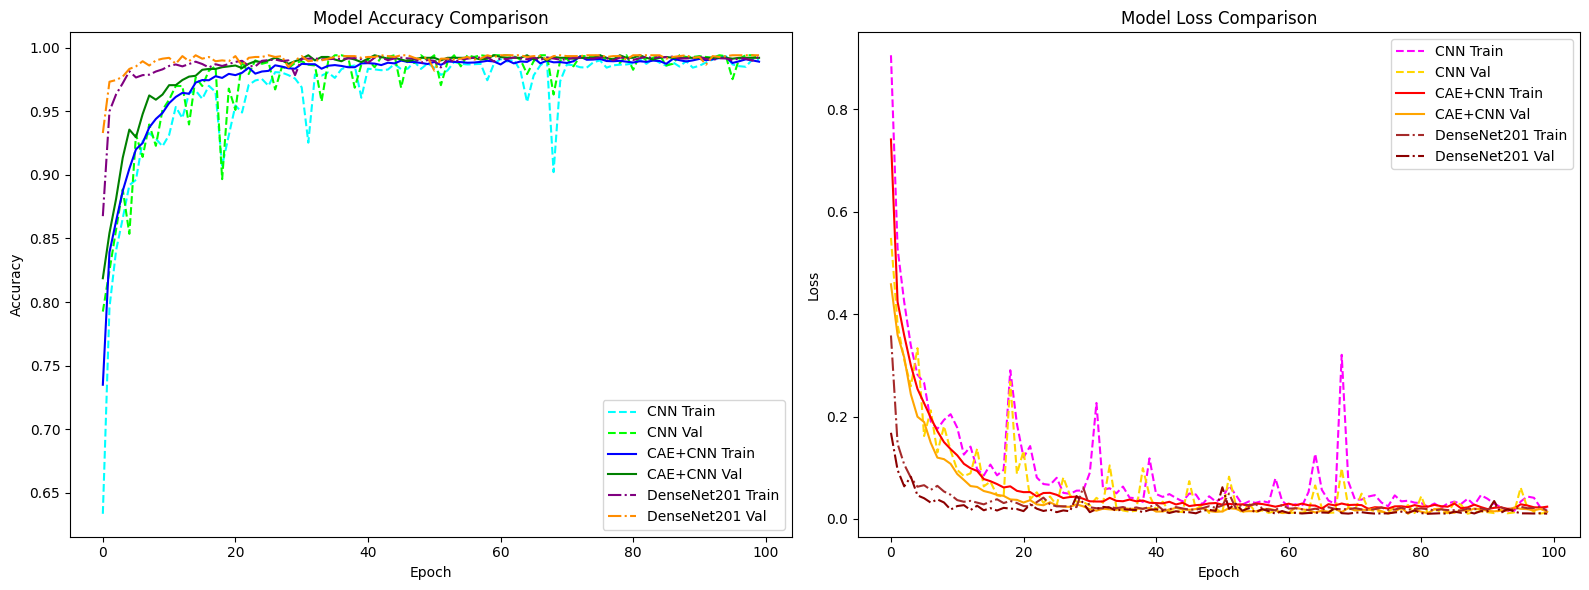

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='CNN Train', linestyle='--', color='cyan')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val', linestyle='--', color='lime')

plt.plot(history_caeCnn.history['accuracy'], label='CAE+CNN Train', linestyle='-', color='blue')
plt.plot(history_caeCnn.history['val_accuracy'], label='CAE+CNN Val', linestyle='-', color='green')

plt.plot(history_densenet.history['accuracy'], label='DenseNet201 Train', linestyle='-.', color='purple')
plt.plot(history_densenet.history['val_accuracy'], label='DenseNet201 Val', linestyle='-.', color='darkorange')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend(loc='lower right')
plt.grid(False)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='CNN Train', linestyle='--', color='magenta')
plt.plot(history_cnn.history['val_loss'], label='CNN Val', linestyle='--', color='gold')

plt.plot(history_caeCnn.history['loss'], label='CAE+CNN Train', linestyle='-', color='red')
plt.plot(history_caeCnn.history['val_loss'], label='CAE+CNN Val', linestyle='-', color='orange')

plt.plot(history_densenet.history['loss'], label='DenseNet201 Train', linestyle='-.', color='brown')
plt.plot(history_densenet.history['val_loss'], label='DenseNet201 Val', linestyle='-.', color='darkred')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Comparison')
plt.legend(loc='upper right')
plt.grid(False)

plt.tight_layout()
plt.show()


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


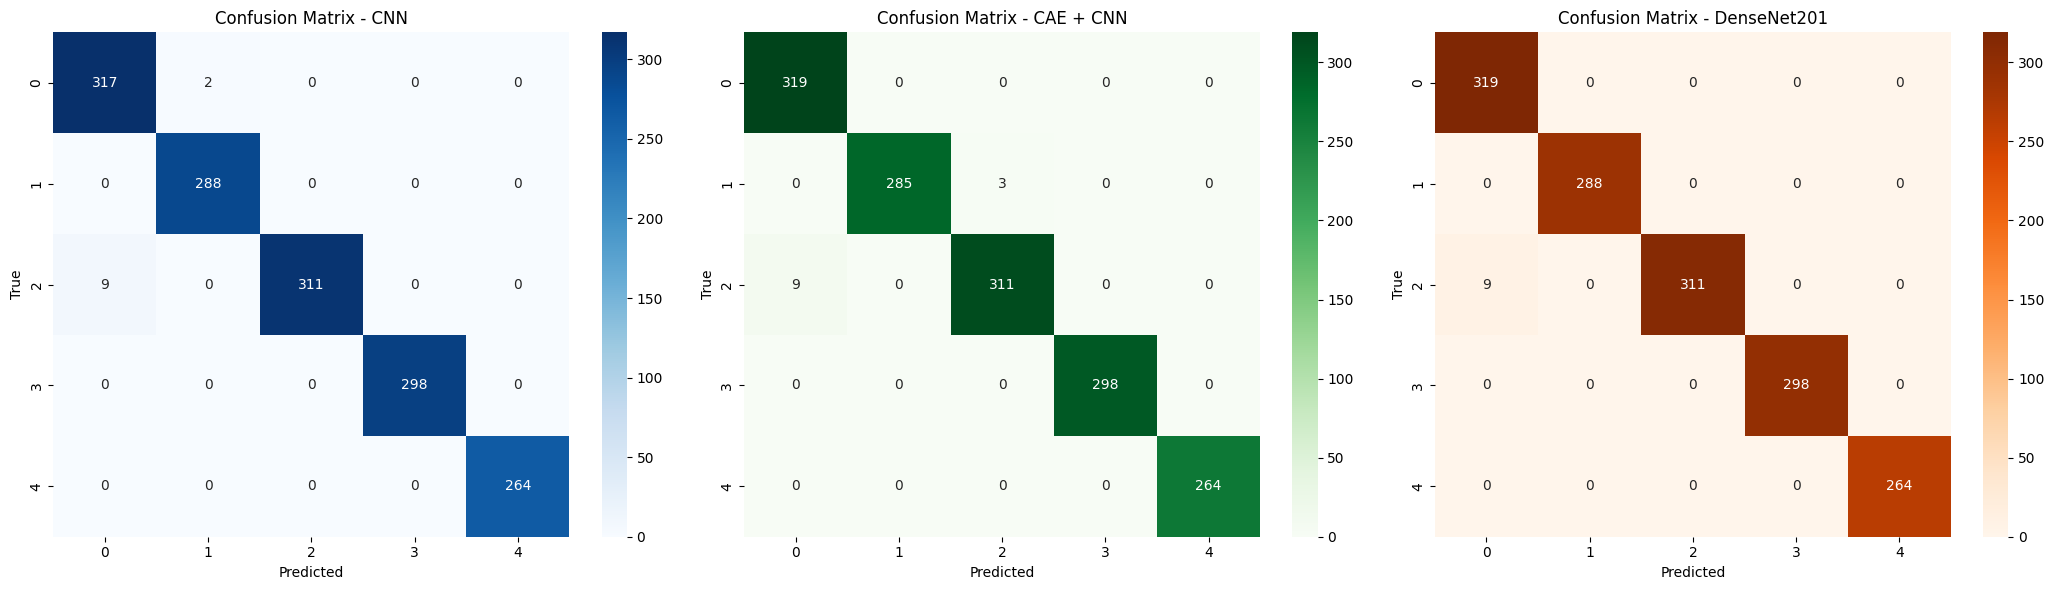

In [ ]:
y_true = np.argmax(y_test, axis=1)

y_pred_cnn = np.argmax(cnn.predict(x_test), axis=1)
y_pred_cae = np.argmax(CaeCnn.predict(encoded_test), axis=1)
y_pred_densenet = np.argmax(denseNet.predict(x_test), axis=1)

cm_cnn = confusion_matrix(y_true, y_pred_cnn)
cm_cae = confusion_matrix(y_true, y_pred_cae)
cm_densenet = confusion_matrix(y_true, y_pred_densenet)

plt.figure(figsize=(21, 6))

plt.subplot(1, 3, 1)
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap='Blues', cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CNN")

plt.subplot(1, 3, 2)
sns.heatmap(cm_cae, annot=True, fmt="d", cmap='Greens', cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - CAE + CNN")

plt.subplot(1, 3, 3)
sns.heatmap(cm_densenet, annot=True, fmt="d", cmap='Oranges', cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DenseNet201")

plt.tight_layout()
plt.show()


In [ ]:
print("=== Classification Report - CNN ===")
print(classification_report(y_true, y_pred_cnn, target_names=valid_class_names))
print("=== Classification Report - CAE + CNN ===")
print(classification_report(y_true, y_pred_cae, target_names=valid_class_names))
print("=== Classification Report - DenseNet ===")
print(classification_report(y_true, y_pred_densenet, target_names=valid_class_names))

=== Classification Report - CNN ===
                 precision    recall  f1-score   support

Bacterialblight       0.97      0.99      0.98       319
          Blast       0.99      1.00      1.00       288
      Brownspot       1.00      0.97      0.99       320
        Healthy       1.00      1.00      1.00       298
         Tungro       1.00      1.00      1.00       264

       accuracy                           0.99      1489
      macro avg       0.99      0.99      0.99      1489
   weighted avg       0.99      0.99      0.99      1489

=== Classification Report - CAE + CNN ===
                 precision    recall  f1-score   support

Bacterialblight       0.97      1.00      0.99       319
          Blast       1.00      0.99      0.99       288
      Brownspot       0.99      0.97      0.98       320
        Healthy       1.00      1.00      1.00       298
         Tungro       1.00      1.00      1.00       264

       accuracy                           0.99      1489
     